# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026 — posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check — the best precision any measurement can claim — that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x` —
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts — your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution — it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately — you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how — and what the background has to do with it — is the
point.)

Number of photons: 812
Sample standard deviation: 10.331 pixels
Naive position estimate: 34.200 ± 0.363 pixels


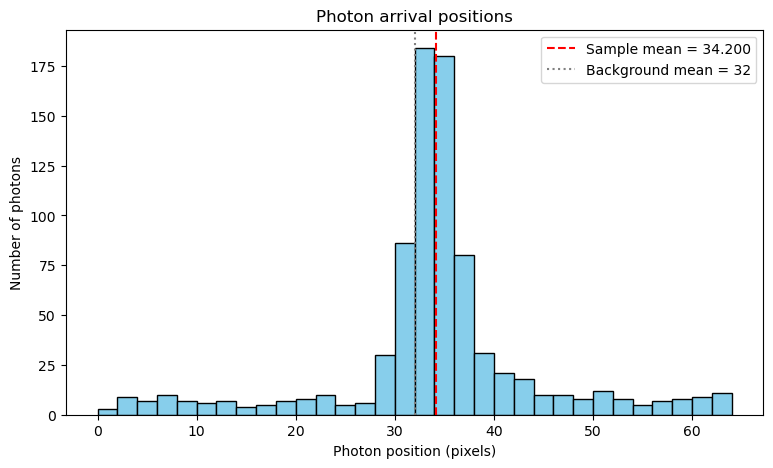

In [23]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt("data/siyaoxu2.csv", delimiter=",", skiprows=1)

N = len(x)
x_mean = np.mean(x)
s = np.std(x, ddof=1)
sigma = s / np.sqrt(N)

print(f"Number of photons: {N}")
print(f"Sample standard deviation: {s:.3f} pixels")
print(f"Naive position estimate: {x_mean:.3f} ± {sigma:.3f} pixels")

bins = np.arange(0, 66, 2)

plt.figure(figsize=(9, 5))
plt.hist(x, bins=bins, color="skyblue", edgecolor="black")
plt.axvline(x_mean, color="red", linestyle="--",
            label=f"Sample mean = {x_mean:.3f}")
plt.axvline(32, color="gray", linestyle=":",
            label="Background mean = 32")
plt.xlabel("Photon position (pixels)")
plt.ylabel("Number of photons")
plt.title("Photon arrival positions")
plt.legend()
plt.show()

**ANSWER (a few sentences):**

Using all 812 photons, I obtain a naive position estimate of 34.200 ± 0.363 pixels, where the uncertainty is the sample standard deviation divided by √N. I chose 2 pixel wide histogram bins to show the central peak while limiting noise in individual bins. The peak appears to lie above 32 pixels, so I expect the uniform background to pull the sample mean toward 32 and underestimate the star’s position. Neglecting the small effect of truncating the stellar profile at the detector edges, the bias is approximately f_bg(32 − x₀), so its size increases with the background fraction and the star’s distance from 32. The reported standard error describes random sampling uncertainty and does not account for this systematic bias.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple — but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery — this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate — numerically over the window is fine — and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible — and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer** — one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper — and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [22]:
# Part 2: your work here
import numpy as np
from scipy.optimize import minimize
from scipy.special import gamma
from scipy.integrate import quad

x = np.loadtxt("data/siyaoxu2.csv", delimiter=",", skiprows=1)
N = len(x)

x_median = np.median(x)

kept = x.copy()

for iteration in range(100):
    center = np.mean(kept)
    spread = np.std(kept, ddof=1)

    new_kept = kept[np.abs(kept - center) <= 3 * spread]

    if len(new_kept) == len(kept):
        break

    kept = new_kept
else:
    raise RuntimeError("Sigma clipping did not converge.")

x_clipped = np.mean(kept)

print(f"Ordinary mean: {np.mean(x):.3f} pixels")
print(f"Median: {x_median:.3f} pixels")
print(f"Clipped mean: {x_clipped:.3f} pixels")
print(f"Photons retained: {len(kept)} / {N}")
beta = 2.5
r0 = 4.0

A = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def star_pdf(z, x0):
    return A * (1 + ((z - x0) / r0)**2)**(-beta)

def mixture_pdf(z, x0, f_bg):
    return f_bg / 64 + (1 - f_bg) * star_pdf(z, x0)

def nll(params):
    x0, f_bg = params
    p = mixture_pdf(x, x0, f_bg)
    return -np.sum(np.log(p))

starts = [
    [x_median, 0.3],
    [30.0, 0.1],
    [38.0, 0.6]
]

fits = [
    minimize(
        nll,
        start,
        method="L-BFGS-B",
        bounds=[(0, 64), (0.000001, 0.999999)]
    )
    for start in starts
]

successful = [fit for fit in fits if fit.success]

if not successful:
    raise RuntimeError("The fit failed.")

result = min(successful, key=lambda fit: fit.fun)
x_mle, f_mle = result.x

print(f"MLE position: {x_mle:.3f} pixels")
print(f"Background fraction: {f_mle:.4f}")
theta = result.x
steps = np.array([0.001, 0.0001])

H = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        ei = np.zeros(2)
        ej = np.zeros(2)

        ei[i] = steps[i]
        ej[j] = steps[j]

        H[i, j] = (
            nll(theta + ei + ej)
            - nll(theta + ei - ej)
            - nll(theta - ei + ej)
            + nll(theta - ei - ej)
        ) / (4 * steps[i] * steps[j])

covariance = np.linalg.inv(H)

sigma_x = np.sqrt(covariance[0, 0])
sigma_f = np.sqrt(covariance[1, 1])

print(f"x0 = {x_mle:.3f} ± {sigma_x:.3f} pixels")
print(f"f_bg = {f_mle:.4f} ± {sigma_f:.4f}")

def pdf_derivatives(z):
    q = star_pdf(z, x_mle)

    dq_dx0 = (
        q * 2 * beta * (z - x_mle)
        / (r0**2 + (z - x_mle)**2)
    )

    dp_dx0 = (1 - f_mle) * dq_dx0
    dp_df = 1 / 64 - q

    return np.array([dp_dx0, dp_df])

F = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        def integrand(z):
            derivatives = pdf_derivatives(z)
            p = mixture_pdf(z, x_mle, f_mle)
            return derivatives[i] * derivatives[j] / p

        F[i, j] = quad(integrand, 0, 64)[0]

cr_covariance = np.linalg.inv(N * F)
sigma_crb = np.sqrt(cr_covariance[0, 0])

print(f"Cramer-Rao bound: {sigma_crb:.4f} pixels")
print(f"MLE uncertainty / bound: {sigma_x / sigma_crb:.3f}")
print(f"3 × bound: {3 * sigma_crb:.4f} pixels")

Ordinary mean: 34.200 pixels
Median: 34.102 pixels
Clipped mean: 34.250 pixels
Photons retained: 628 / 812
MLE position: 34.054 pixels
Background fraction: 0.3015
x0 = 34.054 ± 0.108 pixels
f_bg = 0.3015 ± 0.0196
Cramer-Rao bound: 0.1068 pixels
MLE uncertainty / bound: 1.008
3 × bound: 0.3204 pixels


**FINAL ANSWER:** $x_0 = $ 34.054 $\pm$ 0.108 px , $f_{\rm bg} = $ 0.3015 $\pm$ 0.0196 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.1068 px

**Justification and uncertainty method (a short paragraph):**

FINAL ANSWER: x₀ = 34.054 ± 0.108 px, f_bg = 0.3015 ± 0.0196, and σ_CRB = 0.1068 px.

I choose the mixture-model MLE because it explicitly accounts for both stellar and background photons. I estimated its uncertainties from the inverse of the full 2 × 2 Hessian of the negative log-likelihood at the optimum, including the coupling between position and background fraction. I evaluated the full Fisher information matrix numerically over [0, 64] at the fitted parameters. The position uncertainty is about 1.008 times the estimated Cramér–Rao bound and satisfies the 3× requirement. These calculations use the permitted approximation of negligible stellar photon loss outside the window; their reliability still needs to be checked through the Part 3 simulations.

The median is 34.102 px. Iterative 3σ clipping gives 34.250 px and retains 628 of the 812 photons. I chose a 3σ threshold to remove distant photons without clipping too aggressively, although it can still remove stellar photons and retain background. Neither the median nor the clipped mean is guaranteed to be unbiased. I will compare the bias and empirical variance of all four estimators in Part 3.


## Part 3: The verification plan — written first, then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound —
   this is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found — including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

I have already inspected the real data in Parts 1 and 2. This plan specifies the simulation checks before running them.

1. Closure: I will simulate 812 detected photons with known parameters x₀ = 34 pixels and f_bg = 0.30, using β = 2.5 and r₀ = 4. Stellar photons will follow the corresponding Student-t distribution, restricted to the detector window, and background photons will be uniform over [0, 64]. I will flag a failed fit, invalid uncertainty, or either fitted parameter differing from its truth by more than three estimated standard errors. One successful example will not be treated as proof of reliability.

2. Bias and efficiency: I will run 1,000 simulations at (x₀, f_bg) = (34, 0.30), and 500 each at (24, 0.15) and (40, 0.45). I will apply the mean, median, iterative 3σ-clipped mean, and mixture-model MLE to every dataset. I will calculate their bias, empirical variance, and mean squared error. Bias exceeding three Monte Carlo standard errors will be flagged. I will compare empirical variance with the CRB variance obtained from the full two-parameter Fisher matrix at the generating truth. For a method without detected bias, variance greater than twice the bound will be my practical inefficiency criterion. The ordinary unbiased CRB does not apply directly to biased estimators.

3. Coverage: I will check whether estimate ± estimated standard error contains the known truth approximately 68.27% of the time. I will use s/√N for the mean, the large-sample density formula for the median, the provisional retained-sample SEM for the clipped mean, and inverse-Hessian errors for MLE. The clipped SEM may fail because it ignores adaptive selection. Coverage differing from 0.6827 by more than 3√[0.6827(1 − 0.6827)/M] will be flagged, where M is the number of simulations. Failed intervals will count as noncoverage. These are individual diagnostic flags, not a simultaneous hypothesis test.

4. Sensitivity: I will change β and r₀ separately by ±10%, calculate the stellar fraction lost outside the detector, and compare approximate and exactly normalized likelihoods. A real-data position shift larger than the nominal MLE standard error will flag material sensitivity. I will also simulate 300 edge-case datasets at x₀ = 4 and f_bg = 0.30, where photon loss may matter. Finally, I will compare clipping thresholds 2.5σ, 3σ, 3.5σ, and 4σ on the same baseline simulations and on the real data. I will retain the original 3σ method in the main comparison rather than retrospectively changing the original choice.

I will use fixed random seeds, report failed and surprising checks, and interpret the results only within the tested models and parameter settings.


In [13]:
# Part 3b: execute the plan here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.integrate import quad
from scipy.special import gamma
from scipy.stats import t
from IPython.display import display

x = np.loadtxt("data/siyaoxu2.csv", delimiter=",", skiprows=1)
N = len(x)

METHODS = ["Mean", "Median", "3-sigma clipped", "MLE"]
TARGET = 0.6827


def stellar_terms(z, x0, beta=2.5, r0=4.0, normalized=False):
    z = np.asarray(z)

    A = gamma(beta) / (
        r0 * np.sqrt(np.pi) * gamma(beta - 0.5)
    )

    q = A * (1 + ((z - x0) / r0)**2)**(-beta)

    dq = (
        q * 2 * beta * (z - x0)
        / (r0**2 + (z - x0)**2)
    )

    if normalized:
        nu = 2 * beta - 1
        scale = r0 / np.sqrt(nu)

        Z = (
            t.cdf((64 - x0) / scale, nu)
            - t.cdf(-x0 / scale, nu)
        )

        left = A * (1 + (x0 / r0)**2)**(-beta)
        right = A * (1 + ((64 - x0) / r0)**2)**(-beta)
        dZ = left - right

        dq = dq / Z - q * dZ / Z**2
        q = q / Z

    return q, dq


def density(z, theta, beta=2.5, r0=4.0, normalized=False):
    x0, f = theta

    q, dq = stellar_terms(
        z, x0, beta, r0, normalized
    )

    p = f / 64 + (1 - f) * q

    derivatives = np.array([
        (1 - f) * dq,
        np.ones_like(q) / 64 - q
    ])

    return p, derivatives


def curvature_errors(objective, theta):
    steps = np.array([0.001, 0.0001])
    H = np.zeros((2, 2))

    for j in range(2):
        step = np.zeros(2)
        step[j] = steps[j]

        H[:, j] = (
            objective(theta + step)[1]
            - objective(theta - step)[1]
        ) / (2 * steps[j])

    H = (H + H.T) / 2

    if np.min(np.linalg.eigvalsh(H)) <= 0:
        return np.array([np.nan, np.nan])

    return np.sqrt(np.diag(np.linalg.inv(H)))


def fit_mle(data, beta=2.5, r0=4.0, normalized=False):

    def objective(theta):
        p, derivatives = density(
            data, theta, beta, r0, normalized
        )

        negative_log_likelihood = -np.log(p).sum()
        gradient = -(derivatives / p).sum(axis=1)

        return negative_log_likelihood, gradient

    starts = [
        (np.median(data), 0.2),
        (np.median(data), 0.6),
        (np.mean(data), 0.3)
    ]

    results = [
        minimize(
            objective,
            start,
            jac=True,
            method="L-BFGS-B",
            bounds=[(0, 64), (0.00001, 0.99999)]
        )
        for start in starts
    ]

    valid = [
        result for result in results
        if result.success and np.isfinite(result.fun)
    ]

    if not valid:
        return (
            np.full(2, np.nan),
            np.full(2, np.nan),
            False
        )

    result = min(valid, key=lambda result: result.fun)
    errors = curvature_errors(objective, result.x)

    ok = bool(
        np.all(np.isfinite(errors))
        and np.all(errors > 0)
    )

    return result.x, errors, ok


def clipped_estimate(data, k=3.0):
    kept = np.array(data, copy=True)

    for _ in range(100):
        center = np.mean(kept)
        sd = np.std(kept, ddof=1)

        new = kept[np.abs(kept - center) <= k * sd]

        if len(new) == len(kept):
            provisional_error = sd / np.sqrt(len(kept))
            return center, provisional_error, len(kept)

        if len(new) < 2:
            raise RuntimeError(
                "Clipping retained fewer than two photons."
            )

        kept = new

    raise RuntimeError(
        "Clipping did not converge in 100 iterations."
    )


def simulate(rng, n, x0, f_bg, beta=2.5, r0=4.0):
    background = rng.random(n) < f_bg
    data = np.empty(n)

    data[background] = rng.uniform(
        0, 64, background.sum()
    )

    nu = 2 * beta - 1
    scale = r0 / np.sqrt(nu)

    star = (
        x0
        + scale * rng.standard_t(nu, (~background).sum())
    )

    outside = (star < 0) | (star > 64)

    while outside.any():
        star[outside] = (
            x0
            + scale * rng.standard_t(nu, outside.sum())
        )
        outside = (star < 0) | (star > 64)

    data[~background] = star

    return data


def fisher_variance(x0, f_bg, n):
    F = np.zeros((2, 2))

    for i in range(2):
        for j in range(2):

            def integrand(z):
                p, d = density(
                    z, (x0, f_bg), normalized=True
                )
                return d[i] * d[j] / p

            F[i, j] = quad(
                integrand, 0, 64, epsabs=1e-10
            )[0]

    return np.linalg.inv(n * F)[0, 0]


print(f"Loaded {N} photon positions.")

Loaded 812 photon positions.


In [14]:
closure_data = simulate(
    np.random.default_rng(45702),
    N,
    34.0,
    0.30
)

closure_theta, closure_sigma, closure_ok = fit_mle(
    closure_data
)

closure_z = (
    closure_theta - [34.0, 0.30]
) / closure_sigma

closure_table = pd.DataFrame({
    "parameter": ["x0", "f_bg"],
    "truth": [34.0, 0.30],
    "estimate": closure_theta,
    "estimated_SE": closure_sigma,
    "difference_in_SE": closure_z,
    "flag": (
        (not closure_ok)
        | (np.abs(closure_z) > 3)
    )
})

display(closure_table.round(5))

,parameter,truth,estimate,estimated_SE,difference_in_SE,flag
0,x0,34.0,33.97501,0.10838,-0.23061,False
1,f_bg,0.3,0.31598,0.01975,0.80920,False


In [15]:
def run_trials(x0, f_bg, M, seed, compare_thresholds=False):
    rng = np.random.default_rng(seed)

    estimates = np.full((M, 4), np.nan)
    errors = np.full((M, 4), np.nan)

    f_estimates = np.full(M, np.nan)
    f_errors = np.full(M, np.nan)

    k_values = [2.5, 3.0, 3.5, 4.0]
    k_estimates = np.full((M, 4), np.nan)
    k_errors = np.full((M, 4), np.nan)

    bad_fits = 0
    bad_clips = 0

    for trial in range(M):
        data = simulate(rng, N, x0, f_bg)

        estimates[trial, 0] = np.mean(data)
        errors[trial, 0] = (
            np.std(data, ddof=1) / np.sqrt(N)
        )

        estimates[trial, 1] = np.median(data)

        try:
            (
                estimates[trial, 2],
                errors[trial, 2],
                _
            ) = clipped_estimate(data)

        except RuntimeError:
            bad_clips += 1

        theta, se, ok = fit_mle(data)

        if ok:
            estimates[trial, 3] = theta[0]
            errors[trial, 3] = se[0]

            f_estimates[trial] = theta[1]
            f_errors[trial] = se[1]

            p_at_median, _ = density(
                estimates[trial, 1], theta
            )

            errors[trial, 1] = (
                1 / (2 * np.sqrt(N) * p_at_median)
            )

        else:
            bad_fits += 1

        if compare_thresholds:
            for j, k in enumerate(k_values):
                try:
                    (
                        k_estimates[trial, j],
                        k_errors[trial, j],
                        _
                    ) = clipped_estimate(data, k)

                except RuntimeError:
                    pass

    return dict(
        x0=x0,
        f_bg=f_bg,
        M=M,
        estimates=estimates,
        errors=errors,
        f_estimates=f_estimates,
        f_errors=f_errors,
        bad_fits=bad_fits,
        bad_clips=bad_clips,
        k_estimates=k_estimates,
        k_errors=k_errors,
        cr_variance=fisher_variance(x0, f_bg, N)
    )


def summarize(
    estimates, errors, truth, labels, cr_variance=None
):
    rows = []
    M = len(estimates)

    coverage_tolerance = (
        3 * np.sqrt(TARGET * (1 - TARGET) / M)
    )

    for j, label in enumerate(labels):
        values = estimates[:, j]
        se = errors[:, j]

        good = np.isfinite(values)

        valid_interval = (
            good
            & np.isfinite(se)
            & (se > 0)
        )

        bias = np.mean(values[good]) - truth
        variance = np.var(values[good], ddof=1)

        mc_se = np.sqrt(variance / good.sum())

        covered = (
            valid_interval
            & (np.abs(values - truth) <= se)
        )

        coverage = covered.sum() / M

        row = dict(
            method=label,
            bias_px=bias,
            bias_MC_SE=mc_se,
            empirical_SD_px=np.sqrt(variance),
            variance_px2=variance,
            MSE_px2=np.mean(
                (values[good] - truth)**2
            ),
            mean_reported_SE=np.mean(se[valid_interval]),
            coverage=coverage,
            interval_failures=int(
                (~valid_interval).sum()
            ),
            bias_flag=bool(
                abs(bias) > 3 * mc_se
            ),
            coverage_flag=bool(
                abs(coverage - TARGET)
                > coverage_tolerance
            )
        )

        if cr_variance is not None:
            row["variance_over_CRB"] = (
                variance / cr_variance
            )

            row["inefficiency_flag"] = bool(
                not row["bias_flag"]
                and variance > 2 * cr_variance
            )

        rows.append(row)

    return pd.DataFrame(rows)


scenarios = [
    (34.0, 0.30, 1000),
    (24.0, 0.15, 500),
    (40.0, 0.45, 500)
]

trial_results = []
summary_tables = []

for index, (x0, f_bg, M) in enumerate(scenarios):
    trials = run_trials(
        x0,
        f_bg,
        M,
        45703 + index,
        compare_thresholds=(index == 0)
    )

    table = summarize(
        trials["estimates"],
        trials["errors"],
        x0,
        METHODS,
        trials["cr_variance"]
    )

    trial_results.append(trials)
    summary_tables.append(table)

    print(
        f"\nTruth: x0={x0}, f_bg={f_bg}; "
        f"{M} simulations"
    )

    print(
        f"MLE failures: {trials['bad_fits']}; "
        f"clipping failures: {trials['bad_clips']}"
    )

    print(
        f"CRB standard deviation: "
        f"{np.sqrt(trials['cr_variance']):.5f} pixels"
    )

    display(table.round(5))

    f_coverage = np.mean(
        np.abs(trials["f_estimates"] - f_bg)
        <= trials["f_errors"]
    )

    f_bias = (
        np.nanmean(trials["f_estimates"]) - f_bg
    )

    print(
        f"MLE background fraction: "
        f"bias={f_bias:.5f}, "
        f"coverage={f_coverage:.3f}"
    )


Truth: x0=34.0, f_bg=0.3; 1000 simulations
MLE failures: 0; clipping failures: 0
CRB standard deviation: 0.10665 pixels


,method,bias_px,bias_MC_SE,empirical_SD_px,variance_px2,MSE_px2,mean_reported_SE,coverage,interval_failures,bias_flag,coverage_flag,variance_over_CRB,inefficiency_flag
0,Mean,-0.58331,0.01153,0.36465,0.13297,0.47308,0.36560,0.264,0,True,True,11.69014,False
1,Median,-0.06515,0.00389,0.12308,0.01515,0.01938,0.12935,0.637,0,True,True,1.33192,False
2,3-sigma clipped,-0.09055,0.01079,0.34120,0.11642,0.12450,0.16937,0.512,0,True,True,10.23519,False
3,MLE,-0.00007,0.00337,0.10670,0.01138,0.01137,0.10673,0.695,0,False,False,1.00090,False


MLE background fraction: bias=0.00000, coverage=0.675

Truth: x0=24.0, f_bg=0.15; 500 simulations
MLE failures: 0; clipping failures: 0
CRB standard deviation: 0.09331 pixels


,method,bias_px,bias_MC_SE,empirical_SD_px,variance_px2,MSE_px2,mean_reported_SE,coverage,interval_failures,bias_flag,coverage_flag,variance_over_CRB,inefficiency_flag
0,Mean,1.20171,0.01229,0.27491,0.07557,1.51952,0.28460,0.000,0,True,True,8.67902,False
1,Median,0.11666,0.00437,0.09777,0.00956,0.02315,0.10881,0.462,0,True,True,1.09768,False
2,3-sigma clipped,-0.00069,0.00437,0.09778,0.00956,0.00954,0.09299,0.688,0,False,False,1.09810,False
3,MLE,0.00221,0.00381,0.08530,0.00728,0.00727,0.09327,0.716,0,False,False,0.83568,False


MLE background fraction: bias=0.00004, coverage=0.680

Truth: x0=40.0, f_bg=0.45; 500 simulations
MLE failures: 0; clipping failures: 0
CRB standard deviation: 0.12591 pixels


,method,bias_px,bias_MC_SE,empirical_SD_px,variance_px2,MSE_px2,mean_reported_SE,coverage,interval_failures,bias_flag,coverage_flag,variance_over_CRB,inefficiency_flag
0,Mean,-3.59645,0.02074,0.46385,0.21516,13.14921,0.46243,0.000,0,True,True,13.57187,False
1,Median,-0.53117,0.00753,0.16845,0.02838,0.31046,0.16662,0.020,0,True,True,1.78989,False
2,3-sigma clipped,-3.57961,0.02302,0.51474,0.26495,13.07804,0.46170,0.000,0,True,True,16.71305,False
3,MLE,-0.00578,0.00587,0.13117,0.01721,0.01720,0.12643,0.678,0,False,False,1.08529,False


MLE background fraction: bias=0.00103, coverage=0.654


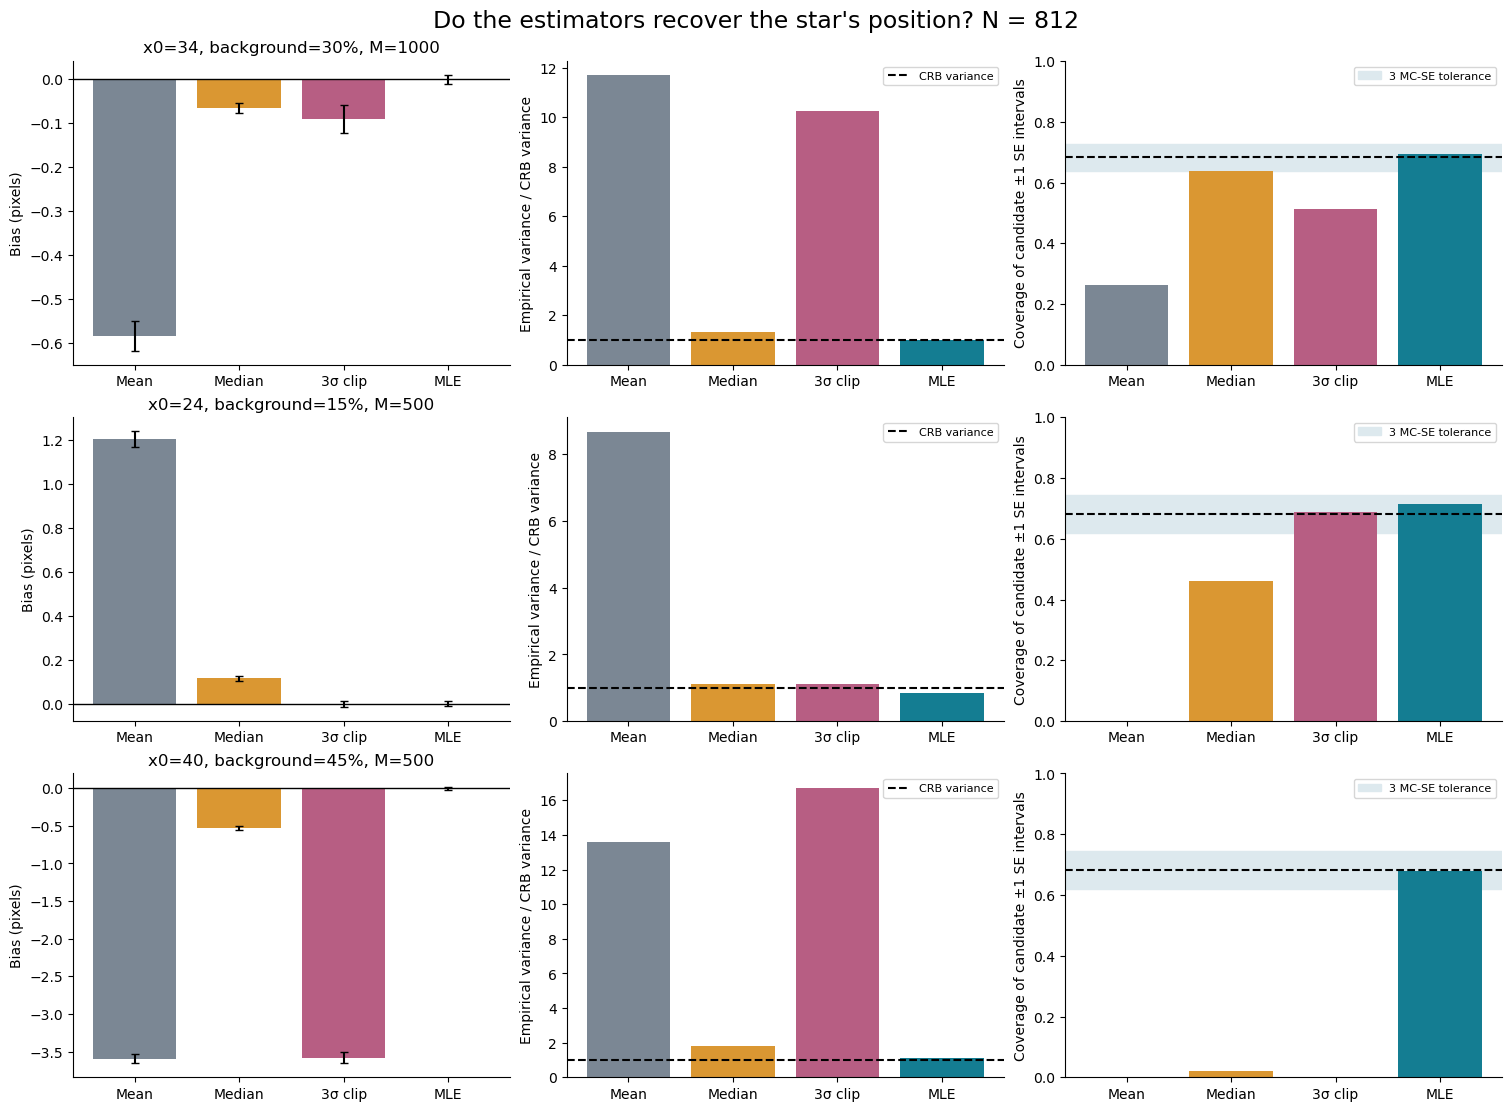

In [16]:
colors = [
    "#7b8794",
    "#da9732",
    "#b75e83",
    "#147d92"
]

fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 11),
    constrained_layout=True
)

for row, (trials, table) in enumerate(
    zip(trial_results, summary_tables)
):
    positions = np.arange(4)
    bias_ax, variance_ax, coverage_ax = axes[row]

    bias_ax.bar(
        positions, table["bias_px"], color=colors
    )

    bias_ax.errorbar(
        positions,
        table["bias_px"],
        yerr=3 * table["bias_MC_SE"],
        fmt="none",
        color="black",
        capsize=3
    )

    bias_ax.axhline(0, color="black", linewidth=1)
    bias_ax.set_ylabel("Bias (pixels)")

    variance_ax.bar(
        positions,
        table["variance_over_CRB"],
        color=colors
    )

    variance_ax.axhline(
        1,
        color="black",
        linestyle="--",
        label="CRB variance"
    )

    variance_ax.set_ylabel(
        "Empirical variance / CRB variance"
    )
    variance_ax.legend(fontsize=8)

    tolerance = 3 * np.sqrt(
        TARGET * (1 - TARGET) / trials["M"]
    )

    coverage_ax.axhspan(
        TARGET - tolerance,
        TARGET + tolerance,
        color="#dde9ee",
        label="3 MC-SE tolerance"
    )

    coverage_ax.bar(
        positions, table["coverage"], color=colors
    )

    coverage_ax.axhline(
        TARGET, color="black", linestyle="--"
    )

    coverage_ax.set_ylim(0, 1)
    coverage_ax.set_ylabel(
        "Coverage of candidate ±1 SE intervals"
    )
    coverage_ax.legend(fontsize=8)

    bias_ax.set_title(
        f"x0={trials['x0']:g}, "
        f"background={trials['f_bg']:.0%}, "
        f"M={trials['M']}"
    )

    for ax in axes[row]:
        ax.set_xticks(
            positions,
            ["Mean", "Median", "3σ clip", "MLE"]
        )
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Do the estimators recover the star's position? N = {N}",
    fontsize=17
)

plt.show()

In [17]:
real_theta, real_errors, real_ok = fit_mle(x)
assert real_ok, "Nominal real-data fit failed."

shape_settings = [
    ("Nominal", 2.5, 4.0, False),
    ("beta -10%", 2.25, 4.0, False),
    ("beta +10%", 2.75, 4.0, False),
    ("r0 -10%", 2.5, 3.6, False),
    ("r0 +10%", 2.5, 4.4, False),
    ("Exact window normalization", 2.5, 4.0, True)
]

shape_rows = []

for label, beta, r0, normalized in shape_settings:
    theta, se, ok = fit_mle(
        x, beta, r0, normalized
    )

    shift = theta[0] - real_theta[0]

    shape_rows.append(dict(
        model=label,
        x0=theta[0],
        f_bg=theta[1],
        x_SE=se[0],
        shift_px=shift,
        shift_in_nominal_SE=shift / real_errors[0],
        flag=bool(
            (not ok)
            or abs(shift) > real_errors[0]
        )
    ))

shape_table = pd.DataFrame(shape_rows)
display(shape_table.round(6))

lost_fraction = (
    t.cdf(-real_theta[0] / 2, 4)
    + t.sf((64 - real_theta[0]) / 2, 4)
)

print(
    f"Stellar fraction outside window: "
    f"{lost_fraction:.8f}"
)

threshold_rows = []

for k in [2.5, 3.0, 3.5, 4.0]:
    center, se, retained = clipped_estimate(x, k)

    threshold_rows.append(dict(
        k=k,
        x0=center,
        provisional_SE=se,
        retained=retained
    ))

threshold_real = pd.DataFrame(threshold_rows)

reference_clip = threshold_real.loc[
    threshold_real.k == 3, "x0"
].iloc[0]

threshold_real["shift_from_3sigma_px"] = (
    threshold_real.x0 - reference_clip
)

threshold_real["shift_flag"] = (
    np.abs(threshold_real.shift_from_3sigma_px)
    > real_errors[0]
)

display(threshold_real.round(5))

baseline = trial_results[0]

threshold_summary = summarize(
    baseline["k_estimates"],
    baseline["k_errors"],
    baseline["x0"],
    ["2.5σ", "3σ", "3.5σ", "4σ"],
    baseline["cr_variance"]
)

display(threshold_summary.round(5))

,model,x0,f_bg,x_SE,shift_px,shift_in_nominal_SE,flag
0,Nominal,34.054013,0.301508,0.107694,0.000000,0.000000,False
1,beta -10%,34.066738,0.286918,0.112510,0.012726,0.118164,False
2,beta +10%,34.042612,0.314264,0.103658,-0.011401,-0.105863,False
3,r0 -10%,34.038738,0.315762,0.101453,-0.015274,-0.141831,False
4,r0 +10%,34.070441,0.289379,0.114119,0.016429,0.152550,False
5,Exact window normalization,34.054040,0.301499,0.107694,0.000027,0.000254,False


Stellar fraction outside window: 0.00009284


,k,x0,provisional_SE,retained,shift_from_3sigma_px,shift_flag
0,2.5,33.99147,0.09664,590,-0.25814,True
1,3.0,34.24962,0.11528,628,0.00000,False
2,3.5,34.19961,0.36254,812,-0.05001,False
3,4.0,34.19961,0.36254,812,-0.05001,False


,method,bias_px,bias_MC_SE,empirical_SD_px,variance_px2,MSE_px2,mean_reported_SE,coverage,interval_failures,bias_flag,coverage_flag,variance_over_CRB,inefficiency_flag
0,2.5σ,0.00237,0.00367,0.11593,0.01344,0.01343,0.09249,0.584,0,False,True,1.18153,False
1,3σ,-0.09055,0.01079,0.34120,0.11642,0.12450,0.16937,0.512,0,True,True,10.23519,False
2,3.5σ,-0.58011,0.01169,0.36968,0.13666,0.47305,0.36541,0.266,0,True,True,12.01491,False
3,4σ,-0.58331,0.01153,0.36465,0.13297,0.47308,0.36560,0.264,0,True,True,11.69014,False


In [18]:
edge_truth = 4.0
edge_f = 0.30
edge_M = 300

edge_rng = np.random.default_rng(45706)

edge_estimates = np.full((edge_M, 2), np.nan)
edge_errors = np.full((edge_M, 2), np.nan)

edge_f_estimates = np.full((edge_M, 2), np.nan)
edge_f_errors = np.full((edge_M, 2), np.nan)

for trial in range(edge_M):
    data = simulate(
        edge_rng, N, edge_truth, edge_f
    )

    for j, normalized in enumerate([False, True]):
        theta, se, ok = fit_mle(
            data, normalized=normalized
        )

        if ok:
            edge_estimates[trial, j] = theta[0]
            edge_errors[trial, j] = se[0]

            edge_f_estimates[trial, j] = theta[1]
            edge_f_errors[trial, j] = se[1]

edge_cr_variance = fisher_variance(
    edge_truth, edge_f, N
)

edge_table = summarize(
    edge_estimates,
    edge_errors,
    edge_truth,
    ["Approximate MLE", "Normalized MLE"],
    edge_cr_variance
)

edge_lost = (
    t.cdf(-edge_truth / 2, 4)
    + t.sf((64 - edge_truth) / 2, 4)
)

print(
    f"Edge-case stellar lost fraction: "
    f"{edge_lost:.4%}"
)

display(edge_table.round(5))

for j, label in enumerate(
    ["Approximate MLE", "Normalized MLE"]
):
    bg_bias = (
        np.nanmean(edge_f_estimates[:, j]) - edge_f
    )

    bg_coverage = np.mean(
        np.abs(edge_f_estimates[:, j] - edge_f)
        <= edge_f_errors[:, j]
    )

    print(
        f"{label}: "
        f"background bias={bg_bias:.5f}, "
        f"coverage={bg_coverage:.3f}"
    )

Edge-case stellar lost fraction: 5.8062%


,method,bias_px,bias_MC_SE,empirical_SD_px,variance_px2,MSE_px2,mean_reported_SE,coverage,interval_failures,bias_flag,coverage_flag,variance_over_CRB,inefficiency_flag
0,Approximate MLE,0.20385,0.00539,0.09329,0.00870,0.05023,0.10160,0.13333,0,True,True,0.74533,False
1,Normalized MLE,0.00364,0.00612,0.10595,0.01123,0.01120,0.10838,0.69333,0,False,False,0.96136,False


Approximate MLE: background bias=0.00272, coverage=0.677
Normalized MLE: background bias=0.00052, coverage=0.663


**WHAT THE CHECKS FOUND:**

The closure test recovered x₀ = 33.9750 ± 0.1084 pixels and f_bg = 0.3160 ± 0.0197, consistent with the chosen truths of 34 and 0.30.

In the 1,000 baseline simulations, the mean, median, 3σ-clipped mean, and MLE had position biases of −0.5833, −0.0651, −0.0906, and approximately −0.0001 pixels, respectively. Their empirical standard deviations were 0.3646, 0.1231, 0.3412, and 0.1067 pixels. The MLE scatter was close to the CRB standard deviation of 0.10665 pixels.

The tested position intervals had coverage of 26.4%, 63.7%, 51.2%, and 69.5%, respectively. Thus, the MLE passed the planned baseline checks, while the other methods triggered bias and coverage flags. The median’s coverage only narrowly triggered the chosen diagnostic threshold. MLE background-fraction coverage was 67.5%.

The clipping results were sensitive to the threshold. A 2.5σ threshold performed better than 3σ in baseline position bias and variance, but its provisional uncertainty still gave only 58.4% coverage. On the real data, changing from 3σ to 2.5σ shifted the position by −0.2581 pixels, larger than the nominal MLE error. Therefore, retaining most stellar photons in an ideal window does not establish that the iterative clipping algorithm or its retained sample SEM is reliable.

At the two additional parameter settings, MLE position coverage was 71.6% and 67.8%, both within the planned tolerance. Its variance/CRB ratio was 0.84 in the low background setting. This finite-simulation result is not evidence of beating the bound; Monte Carlo fluctuations and possible finite-sample bias must be considered.

Changing β or r₀ by ±10% shifted the real-data MLE position by at most 0.01643 pixels, smaller than its 0.10769-pixel error. The stellar fraction outside the real-data window was approximately 0.009284%, and exact window normalization changed the position by only 0.000027 pixels.

The edge test demonstrated a failure of the negligible-loss approximation. At x₀ = 4, about 5.806% of stellar photons fell outside the window. The approximate MLE had position bias +0.2038 pixels and 13.3% coverage; the normalized model reduced the bias to +0.0036 pixels and gave 69.3% coverage.

These checks support retaining the Part 2 mixture-model estimate, x₀ = 34.054 ± 0.108 pixels and f_bg = 0.3015 ± 0.0196, under the tested assumptions. They also show why the clipping failures and the detector-edge correction need to be reported.


## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week — it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I used ChatGPT/Codex to help write and explain the Python code, interpret results, and draft the written answers. It also drafted the Part 3 verification plan and simulation code and ran the checks before I ran the supplied code in my notebook.

One weakness was its initial justification for choosing a 3σ clipping threshold. It described 3σ as a reasonable compromise without first testing whether that choice worked for this Moffat-plus-background model. I questioned this after my professor’s warning about AI choosing standard thresholds without sufficient justification.

ChatGPT then calculated how many stellar and background photons an ideal 3σ window would retain. However, this did not establish that the actual iterative algorithm, which estimates its standard deviation from contaminated data, would reliably find that window. The subsequent simulations exposed this limitation: the original 3σ method had only 51.2% coverage using its provisional retained-sample standard error, compared with the target of about 68%.

The correction was to withdraw the unsupported claim of reliability, report the failed check, and compare alternative thresholds. We retained the original 3σ results for transparency and selected the mixture-model MLE as the final estimator because the simulations better supported its bias and uncertainty estimates.
